# 04 — Sentinel-1 Multitemporal LULC Classification

## Single-period SAR vs Full-year Multitemporal SAR
**Google Earth Engine Python API + Google Colab**

**พื้นที่ศึกษา:** อำเภอเมืองพิษณุโลก จังหวัดพิษณุโลก  
**ข้อมูล:** Sentinel-1 GRD, ปี 2021  
**ระดับ:** ปริญญาตรีปี 4 / ปริญญาโทด้านสิ่งแวดล้อม

Notebook นี้นำความรู้จาก Notebook 01–03 มารวมกัน

```text
Notebook 01
Supervised classification
        +
Notebook 02
Rectangle training
        +
Notebook 03
Sentinel-1 temporal backscatter
        ↓
Notebook 04
Multitemporal SAR classification
```

คำถามหลัก:

> **ข้อมูล Sentinel-1 หลายช่วงเวลาช่วยจำแนก LULC ได้ดีกว่าข้อมูลช่วงเดียวหรือไม่?**

และ

> **เดือนไหน / polarization ใดมีบทบาทต่อ Random Forest มากที่สุด?**

## Learning objectives

เมื่อจบ Notebook นี้ ผู้เรียนควรสามารถ

1. สร้าง Sentinel-1 collection ที่มี acquisition geometry สม่ำเสมอ
2. อธิบายความแตกต่างระหว่าง GRD asset count และ independent acquisition dates
3. mosaic GRD frames ที่อยู่ในวันเดียวกันก่อนทำ temporal composite
4. สร้าง January VV/VH baseline model
5. สร้าง full-year 24-band VV/VH model
6. ใช้ training rectangles และ validation points ชุดเดิมอย่างถูกต้อง
7. เปรียบเทียบ OA, PA, UA และ F1 ระหว่าง single-period กับ annual model
8. วิเคราะห์ Random Forest variable importance
9. รวม importance ตามเดือนและ polarization
10. อธิบายข้อจำกัดเรื่อง temporal consistency ของ reference labels
11. export classified GeoTIFF สำหรับ QGIS

# Part 1 — What did Notebook 03 tell us?

ผลจาก Notebook 03 แสดงว่า Sentinel-1 ในพื้นที่ศึกษามีข้อมูลครอบคลุมตลอดปีและสามารถสร้าง monthly VV/VH ได้ครบ 12 เดือน

แนวโน้มที่เห็นจาก temporal profiles:

- **Water** มี backscatter ต่ำและค่อนข้างเสถียร
- **Urban** มี backscatter สูง
- **Forest** มี VV/VH ค่อนข้างสูงและหลายช่วงใกล้ Urban
- **Agriculture** มี temporal variability ชัด
- **Bare soil** มี temporal variability และบางช่วงใกล้ Agriculture

ดังนั้น Notebook 04 จะทดสอบสมมติฐานว่า

$$
\text{Temporal information}
\rightarrow
\text{better separability for some classes}
$$

แต่จะไม่สมมติล่วงหน้าว่า annual model ต้องดีกว่าเสมอ

In [2]:
# Import libraries

import ee
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

print("Earth Engine API version:", ee.__version__)
print("Folium version:", folium.__version__)

Earth Engine API version: 1.7.39
Folium version: 0.20.0


In [3]:
# Authenticate and initialize Google Earth Engine

PROJECT = "teach-gee-github-lulc"

ee.Authenticate()
ee.Initialize(project=PROJECT)

print("Earth Engine initialized successfully.")

Earth Engine initialized successfully.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [4]:
# Mapping helpers and common class definitions

def add_ee_layer(map_object, ee_image, vis_params, name,
                 shown=True, opacity=1.0):
    map_id = ee.Image(ee_image).getMapId(vis_params)

    folium.raster_layers.TileLayer(
        tiles=map_id["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        name=name,
        overlay=True,
        control=True,
        show=shown,
        opacity=opacity,
    ).add_to(map_object)


def add_esri_imagery(map_object, shown=False):
    folium.TileLayer(
        tiles=(
            "https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}"
        ),
        attr="Esri, Maxar, Earthstar Geographics, and the GIS User Community",
        name="Esri World Imagery",
        overlay=False,
        control=True,
        show=shown,
    ).add_to(map_object)


CLASS_COLORS = {
    0: "#d73027",
    1: "#2166ac",
    2: "#1a9850",
    3: "#fee08b",
    4: "#a6611a",
}

CLASS_NAMES = {
    0: "Urban",
    1: "Water",
    2: "Forest",
    3: "Agriculture",
    4: "Bare soil",
}

CLASS_ORDER = [0, 1, 2, 3, 4]

CLASS_PALETTE = [
    CLASS_COLORS[i].replace("#", "")
    for i in CLASS_ORDER
]

SEED = 42

# Part 2 — Use the same reference samples

เพื่อให้เปรียบเทียบกับ Notebook 01–02 ได้อย่างเป็นธรรม เราจะใช้

```text
Same 101 reference points
Same fixed split
Same 71 training locations
Same 30 validation locations
Same 20 × 20 m training windows
```

สิ่งที่เปลี่ยนคือ **predictor information**

```text
Model A = January VV + VH
Model B = January–December VV + VH
```

In [5]:
# Load the shared reference CSV

LOCAL_CSV = Path("/content/phitsanulok_lulc_points.csv")

GITHUB_CSV = (
    "https://raw.githubusercontent.com/"
    "nattaponm/Teach-GEE-LULC/main/"
    "data/phitsanulok_lulc_points.csv"
)

if LOCAL_CSV.exists():
    samples_df = pd.read_csv(LOCAL_CSV)
    print("Loaded:", LOCAL_CSV)
else:
    try:
        samples_df = pd.read_csv(GITHUB_CSV)
        print("Loaded from GitHub:", GITHUB_CSV)
    except Exception:
        print(
            "CSV was not found on GitHub yet.\n"
            "Upload phitsanulok_lulc_points.csv to Colab."
        )
        from google.colab import files

        uploaded = files.upload()
        filename = next(iter(uploaded))
        samples_df = pd.read_csv(filename)

samples_df["class_id"] = samples_df["class_id"].astype(int)

display(samples_df.head())

Loaded from GitHub: https://raw.githubusercontent.com/nattaponm/Teach-GEE-LULC/main/data/phitsanulok_lulc_points.csv


,sample_id,longitude,latitude,class_id,class_name,split
0,UR001,100.269879,16.817238,0,Urban,train
1,UR002,100.285468,16.817505,0,Urban,validation
2,UR003,100.256249,16.804334,0,Urban,validation
3,UR004,100.279540,16.782361,0,Urban,train
4,UR005,100.197563,16.753218,0,Urban,validation


In [6]:
# Verify the fixed train / validation split

if "split" not in samples_df.columns:
    raise ValueError(
        "The CSV must contain the fixed 'split' column from Notebook 01."
    )

split_table = pd.crosstab(
    samples_df["class_name"],
    samples_df["split"],
    margins=True,
)

display(split_table)

print("Training locations:",
      (samples_df["split"] == "train").sum())

print("Validation locations:",
      (samples_df["split"] == "validation").sum())

split,train,validation,All
class_name,,,
Agriculture,14,6,20
Bare soil,15,6,21
Forest,14,6,20
Urban,14,6,20
Water,14,6,20
All,71,30,101


Training locations: 71
Validation locations: 30


In [7]:
# Convert reference points to Earth Engine

def dataframe_to_ee_points(df):
    features = []

    for row in df.itertuples(index=False):
        geom = ee.Geometry.Point(
            [float(row.longitude), float(row.latitude)]
        )

        properties = {
            "sample_id": str(row.sample_id),
            "longitude": float(row.longitude),
            "latitude": float(row.latitude),
            "class_id": int(row.class_id),
            "class_name": str(row.class_name),
            "split": str(row.split),
        }

        features.append(
            ee.Feature(geom, properties)
        )

    return ee.FeatureCollection(features)


all_points = dataframe_to_ee_points(samples_df)

training_points = all_points.filter(
    ee.Filter.eq("split", "train")
)

validation_points = all_points.filter(
    ee.Filter.eq("split", "validation")
)

print("Training:", training_points.size().getInfo())
print("Validation:", validation_points.size().getInfo())

Training: 71
Validation: 30


In [8]:
# Study area — same as previous notebooks

roi = ee.Geometry.Point([100.26575, 16.82277])

gaul2 = (
    ee.FeatureCollection("FAO/GAUL/2025/level2")
    .filter(ee.Filter.eq("GAUL0_NAME", "Thailand"))
)

district_fc = gaul2.filterBounds(roi)
study_area = district_fc.geometry()

print("District candidate(s):")
display(district_fc.aggregate_array("DISP_EN").getInfo())

District candidate(s):


['Mueang Phitsanulok, Phitsanulok, Thailand']

# Part 3 — Temporal-label consistency

Reference labels ชุดนี้มาจากการตีความพื้นที่ช่วงต้นปี 2021

สำหรับ class ที่ค่อนข้างคงที่ เช่น

```text
Urban
Water
Forest
```

การใช้ข้อมูลทั้งปีมักสมเหตุสมผลกว่า

แต่สำหรับ

```text
Agriculture
Bare soil
```

สภาพพื้นผิวสามารถเปลี่ยนได้ เช่น

```text
Bare soil → crop → harvest → bare/fallow
```

ดังนั้น full-year model มีสมมติฐานสำคัญว่า

> ตำแหน่งอ้างอิงยังเป็นตัวแทนของ “class concept” ที่เราต้องการเรียนรู้ แม้ว่าสภาพพื้นผิวรายเดือนจะเปลี่ยน

นี่เป็น **teaching experiment** เกี่ยวกับ temporal information  
ไม่ควรตีความว่า class label ทุกชนิดเป็น immutable land cover ตลอดทั้งปี

$$
\text{High accuracy}
\not\Rightarrow
\text{perfect temporal label definition}
$$

# Part 4 — Build a homogeneous Sentinel-1 collection

เราจะทำเหมือน Notebook 03

```text
Sentinel-1 GRD
      ↓
2021
      ↓
IW mode
      ↓
VV + VH
      ↓
select orbit pass
      ↓
select relative orbit
```

เหตุผลคือ backscatter ขึ้นกับ acquisition geometry ด้วย ไม่ใช่ land cover เพียงอย่างเดียว

In [9]:
# Load Sentinel-1 IW VV/VH for 2021

YEAR = 2021
START_DATE = f"{YEAR}-01-01"
END_DATE = f"{YEAR + 1}-01-01"

s1_base = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(study_area)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(
        ee.Filter.listContains(
            "transmitterReceiverPolarisation",
            "VV",
        )
    )
    .filter(
        ee.Filter.listContains(
            "transmitterReceiverPolarisation",
            "VH",
        )
    )
)

print("Initial S1 IW VV/VH asset count:",
      s1_base.size().getInfo())

Initial S1 IW VV/VH asset count: 118


In [10]:
# Select the orbit pass with the most scenes

pass_counts = (
    s1_base
    .aggregate_histogram("orbitProperties_pass")
    .getInfo()
)

pass_table = pd.DataFrame(
    sorted(
        pass_counts.items(),
        key=lambda x: x[1],
        reverse=True,
    ),
    columns=["orbit_pass", "n_assets"],
)

display(pass_table)

ORBIT_PASS = max(
    pass_counts,
    key=pass_counts.get,
)

print("Selected orbit pass:", ORBIT_PASS)

,orbit_pass,n_assets
0,DESCENDING,87
1,ASCENDING,31


Selected orbit pass: DESCENDING


In [11]:
# Select the most frequent relative orbit within that pass

s1_pass = s1_base.filter(
    ee.Filter.eq(
        "orbitProperties_pass",
        ORBIT_PASS,
    )
)

relative_counts = (
    s1_pass
    .aggregate_histogram(
        "relativeOrbitNumber_start"
    )
    .getInfo()
)

relative_table = pd.DataFrame(
    [
        {
            "relative_orbit": int(float(k)),
            "n_assets": v,
        }
        for k, v in relative_counts.items()
    ]
).sort_values(
    "n_assets",
    ascending=False,
)

display(relative_table)

RELATIVE_ORBIT = int(
    relative_table.iloc[0]["relative_orbit"]
)

s1_geom = (
    s1_pass
    .filter(
        ee.Filter.eq(
            "relativeOrbitNumber_start",
            RELATIVE_ORBIT,
        )
    )
    .select(["VV", "VH"])
    .sort("system:time_start")
)

print("Selected orbit pass:", ORBIT_PASS)
print("Selected relative orbit:", RELATIVE_ORBIT)
print("GRD assets after geometry filter:",
      s1_geom.size().getInfo())

,relative_orbit,n_assets
0,62,87


Selected orbit pass: DESCENDING
Selected relative orbit: 62
GRD assets after geometry filter: 87


# Part 5 — GRD asset count ≠ independent acquisition count

จาก Notebook 03 เราพบว่าบาง acquisition date มี GRD assets มากกว่าหนึ่งภาพ

เช่น conceptually:

```text
2021-01-05
   ├── frame A
   └── frame B
```

สอง assets นี้ไม่ควรถูกตีความเป็น independent temporal observations สองครั้ง

ดังนั้นก่อนสร้าง monthly composite เราจะ

```text
GRD frames
    ↓
group by acquisition date
    ↓
mosaic same-date frames
    ↓
one image per date
```

ผลคือแต่ละ acquisition date มีน้ำหนักหนึ่งครั้งในการสร้าง monthly temporal composite

In [12]:
# Add date string to every GRD asset

def add_date_property(image):
    date_str = ee.Date(
        image.get("system:time_start")
    ).format("YYYY-MM-dd")

    return image.set(
        "date_str",
        date_str,
    )


s1_dated = s1_geom.map(
    add_date_property
)

asset_count = s1_dated.size().getInfo()

unique_dates = (
    ee.List(
        s1_dated.aggregate_array("date_str")
    )
    .distinct()
    .sort()
)

unique_date_count = unique_dates.size().getInfo()

print("GRD asset count:", asset_count)
print("Unique acquisition dates:", unique_date_count)
print("Repeated-frame assets:",
      asset_count - unique_date_count)

GRD asset count: 87
Unique acquisition dates: 57
Repeated-frame assets: 30


In [13]:
# Inspect dates that contain more than one GRD asset

date_histogram = (
    s1_dated
    .aggregate_histogram("date_str")
    .getInfo()
)

date_count_df = pd.DataFrame(
    [
        {
            "date": date,
            "n_assets": count,
        }
        for date, count in date_histogram.items()
    ]
).sort_values(
    ["n_assets", "date"],
    ascending=[False, True],
)

display(
    date_count_df.head(20)
)

,date,n_assets
0,2021-01-05,2
2,2021-01-17,2
4,2021-01-29,2
6,2021-02-10,2
8,2021-02-22,2
10,2021-03-06,2
12,2021-03-18,2
14,2021-03-30,2
16,2021-04-11,2
18,2021-04-23,2


In [14]:
# Mosaic same-date GRD frames to one image per acquisition date

def mosaic_one_date(date_str):
    date_str = ee.String(date_str)

    same_day = s1_dated.filter(
        ee.Filter.eq(
            "date_str",
            date_str,
        )
    )

    date = ee.Date.parse(
        "YYYY-MM-dd",
        date_str,
    )

    daily = (
        same_day
        .mosaic()
        .select(["VV", "VH"])
        .set("date_str", date_str)
        .set("system:time_start", date.millis())
        .set("orbitProperties_pass", ORBIT_PASS)
        .set("relativeOrbitNumber_start", RELATIVE_ORBIT)
    )

    return daily


s1_daily = ee.ImageCollection.fromImages(
    unique_dates.map(
        mosaic_one_date
    )
).sort("system:time_start")

print("Daily mosaics:",
      s1_daily.size().getInfo())

Daily mosaics: 57


# Part 6 — Monthly temporal composites

หลังจากมีหนึ่ง image ต่อ acquisition date แล้ว จึงสร้าง monthly median

$$
\tilde{\sigma}^{0}_{m}
=
\operatorname{median}
\left(
\sigma^{0}_{t}
\right),
\quad t\in m
$$

ในบทนี้ใช้ monthly median ของ dB เป็น robust temporal representation

In [15]:
# Count independent acquisition dates per month

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec",
]

monthly_counts = []

for month in range(1, 13):
    start = ee.Date.fromYMD(
        YEAR,
        month,
        1,
    )
    end = start.advance(
        1,
        "month",
    )

    n = (
        s1_daily
        .filterDate(start, end)
        .size()
        .getInfo()
    )

    monthly_counts.append({
        "month": month,
        "label": MONTH_LABELS[month - 1],
        "n_acquisition_dates": n,
    })

monthly_counts_df = pd.DataFrame(
    monthly_counts
)

display(monthly_counts_df)

if (monthly_counts_df["n_acquisition_dates"] == 0).any():
    raise ValueError(
        "At least one month has no acquisition. "
        "Revise the orbit selection before continuing."
    )

,month,label,n_acquisition_dates
0,1,Jan,5
1,2,Feb,5
2,3,Mar,5
3,4,Apr,5
4,5,May,4
5,6,Jun,5
6,7,Jul,5
7,8,Aug,4
8,9,Sep,5
9,10,Oct,5


In [16]:
# Build 12 monthly VV/VH median composites

monthly_images = []

for month in range(1, 13):
    label = MONTH_LABELS[month - 1]

    start = ee.Date.fromYMD(
        YEAR,
        month,
        1,
    )
    end = start.advance(
        1,
        "month",
    )

    monthly = (
        s1_daily
        .filterDate(start, end)
        .median()
        .rename([
            f"VV_{label}",
            f"VH_{label}",
        ])
        .set("month", month)
        .set("month_label", label)
    )

    monthly_images.append(monthly)

print("Monthly composites created:",
      len(monthly_images))

Monthly composites created: 12


In [17]:
# Build the annual 24-band feature stack

annual_stack = monthly_images[0]

for image in monthly_images[1:]:
    annual_stack = annual_stack.addBands(
        image
    )

annual_stack = annual_stack.clip(
    study_area
)

ANNUAL_BANDS = annual_stack.bandNames().getInfo()

print("Annual predictors:", len(ANNUAL_BANDS))
display(ANNUAL_BANDS)

Annual predictors: 24


['VV_Jan',
 'VH_Jan',
 'VV_Feb',
 'VH_Feb',
 'VV_Mar',
 'VH_Mar',
 'VV_Apr',
 'VH_Apr',
 'VV_May',
 'VH_May',
 'VV_Jun',
 'VH_Jun',
 'VV_Jul',
 'VH_Jul',
 'VV_Aug',
 'VH_Aug',
 'VV_Sep',
 'VH_Sep',
 'VV_Oct',
 'VH_Oct',
 'VV_Nov',
 'VH_Nov',
 'VV_Dec',
 'VH_Dec']

# Part 7 — Two competing models

## Model A — January SAR baseline

ใกล้ช่วงเวลาที่ reference labels ถูกตีความมากที่สุด

$$
\mathbf{x}^{Jan}_i
=
[
VV_{Jan,i},
VH_{Jan,i}
]
$$

ดังนั้น

$$
p=2
$$

---

## Model B — Annual multitemporal SAR

ใช้ temporal information ทั้งปี

$$
\mathbf{x}^{Annual}_i
=
[
VV_{Jan},VH_{Jan},
\dots,
VV_{Dec},VH_{Dec}
]
$$

ดังนั้น

$$
p=24
$$

ทุกอย่างอื่นคงเดิม:

```text
same training locations
same rectangles
same Random Forest
same seed
same validation points
```

นี่คือ controlled experiment ของ **temporal information**

In [18]:
# Prepare January and annual predictor images

january_predictors = (
    monthly_images[0]
    .select(
        ["VV_Jan", "VH_Jan"]
    )
    .clip(study_area)
)

JANUARY_BANDS = [
    "VV_Jan",
    "VH_Jan",
]

annual_predictors = (
    annual_stack
    .select(ANNUAL_BANDS)
)

print("January predictors:")
display(JANUARY_BANDS)

print("Annual predictor count:",
      len(ANNUAL_BANDS))

January predictors:


['VV_Jan', 'VH_Jan']

Annual predictor count: 24


In [19]:
# Folium — inspect selected months before classification

Map = folium.Map(
    location=[16.82, 100.27],
    zoom_start=10,
    tiles=None,
)

add_esri_imagery(Map, shown=False)

add_ee_layer(
    Map,
    monthly_images[0].select("VH_Jan"),
    {"min": -32, "max": -5},
    "VH January",
    shown=True,
)

add_ee_layer(
    Map,
    monthly_images[4].select("VH_May"),
    {"min": -32, "max": -5},
    "VH May",
    shown=False,
)

add_ee_layer(
    Map,
    monthly_images[8].select("VH_Sep"),
    {"min": -32, "max": -5},
    "VH September",
    shown=False,
)

folium.LayerControl(
    collapsed=False
).add_to(Map)

Map

# Part 8 — Use the same 20 × 20 m training support

จาก Notebook 02:

```text
71 training points
      ↓
approximately 20 × 20 m rectangles
      ↓
multiple training pixels
```

Validation ยังเป็น **30 POINTS เดิม**

เราจะไม่เปลี่ยน sampling design เพราะต้องการทดสอบเฉพาะผลของ predictor information

In [20]:
# Convert training points to approximately 20 × 20 m rectangles

HALF_SIZE_M = 10

def point_to_training_rectangle(feature):
    feature = ee.Feature(feature)

    rectangle = (
        feature.geometry()
        .buffer(HALF_SIZE_M)
        .bounds(maxError=1)
    )

    return ee.Feature(
        rectangle,
        feature.toDictionary()
    )


training_rectangles = training_points.map(
    point_to_training_rectangle
)

print("Training rectangles:",
      training_rectangles.size().getInfo())

print("Validation points:",
      validation_points.size().getInfo())

Training rectangles: 71
Validation points: 30


In [21]:
# Sample January predictors from training rectangles

jan_training_data = january_predictors.sampleRegions(
    collection=training_rectangles,
    properties=[
        "sample_id",
        "class_id",
        "class_name",
    ],
    scale=10,
    geometries=True,
)

print("January training pixel records:",
      jan_training_data.size().getInfo())

display(
    jan_training_data
    .aggregate_histogram("class_id")
    .getInfo()
)

January training pixel records: 262


{'0': 56, '1': 56, '2': 28, '3': 58, '4': 64}

In [22]:
# Sample annual 24-band predictors from the SAME rectangles

annual_training_data = annual_predictors.sampleRegions(
    collection=training_rectangles,
    properties=[
        "sample_id",
        "class_id",
        "class_name",
    ],
    scale=10,
    geometries=True,
)

print("Annual training pixel records:",
      annual_training_data.size().getInfo())

display(
    annual_training_data
    .aggregate_histogram("class_id")
    .getInfo()
)

Annual training pixel records: 262


{'0': 56, '1': 56, '2': 28, '3': 58, '4': 64}

## Independent locations, pixels and predictor dimensions

จำแนกสามแนวคิดนี้ให้ชัด

```text
Independent training locations = 71

Training pixel records
= หลาย pixel จาก rectangles

Predictor dimensions
= 2 หรือ 24 variables ต่อ pixel
```

ดังนั้น

$$
n_{pixels}
\ne
n_{independent\ locations}
$$

และการเพิ่ม

$$
p:2\rightarrow24
$$

ทำให้ model มีข้อมูล temporal มากขึ้น แต่ก็เพิ่ม feature complexity

> จำนวน predictors มากขึ้นไม่ได้รับประกันว่า validation accuracy ต้องสูงขึ้น

# Part 9 — Random Forest

ใช้ configuration เดิมจาก Notebook 01–02

```text
100 trees
seed = 42
```

Random Forest เป็น tree-based algorithm  
จึงไม่จำเป็นต้องทำ z-score หรือ min–max normalization ให้ VV/VH ก่อน train

สำหรับ classification:

$$
\hat{y}
=
\operatorname{mode}
\left[
h_1(\mathbf{x}),
\dots,
h_B(\mathbf{x})
\right]
$$

In [23]:
# Train January baseline Random Forest

jan_classifier = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=100,
        seed=SEED,
    )
    .train(
        features=jan_training_data,
        classProperty="class_id",
        inputProperties=JANUARY_BANDS,
    )
)

print("January RF trained.")

January RF trained.


In [24]:
# Train Annual multitemporal Random Forest

annual_classifier = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=100,
        seed=SEED,
    )
    .train(
        features=annual_training_data,
        classProperty="class_id",
        inputProperties=ANNUAL_BANDS,
    )
)

print("Annual RF trained.")

Annual RF trained.


In [25]:
# Create both classification maps

jan_classified = (
    january_predictors
    .classify(jan_classifier)
    .rename("landcover")
    .clip(study_area)
)

annual_classified = (
    annual_predictors
    .classify(annual_classifier)
    .rename("landcover")
    .clip(study_area)
)

print("Both classification maps created.")

Both classification maps created.


In [26]:
# Folium — January vs Annual classification

class_vis = {
    "min": 0,
    "max": 4,
    "palette": CLASS_PALETTE,
}

Map = folium.Map(
    location=[16.82, 100.27],
    zoom_start=10,
    tiles=None,
)

add_esri_imagery(Map, shown=False)

add_ee_layer(
    Map,
    monthly_images[0].select("VH_Jan"),
    {"min": -32, "max": -5},
    "VH January",
    shown=False,
)

add_ee_layer(
    Map,
    monthly_images[8].select("VH_Sep"),
    {"min": -32, "max": -5},
    "VH September",
    shown=False,
)

add_ee_layer(
    Map,
    jan_classified,
    class_vis,
    "January-only S1 Classification",
    shown=True,
)

add_ee_layer(
    Map,
    annual_classified,
    class_vis,
    "Annual Multitemporal S1 Classification",
    shown=False,
)

legend_html = '''
<div style="
position: fixed;
bottom: 30px;
left: 30px;
z-index: 9999;
background-color: white;
padding: 10px;
border: 1px solid grey;
font-size: 13px;">
<b>LULC classes</b><br>
<span style="color:#d73027;">●</span> 0 Urban<br>
<span style="color:#2166ac;">●</span> 1 Water<br>
<span style="color:#1a9850;">●</span> 2 Forest<br>
<span style="color:#fee08b;">●</span> 3 Agriculture<br>
<span style="color:#a6611a;">●</span> 4 Bare soil
</div>
'''

Map.get_root().html.add_child(
    folium.Element(legend_html)
)

folium.LayerControl(
    collapsed=False
).add_to(Map)

Map

# Part 10 — Validate both models with the SAME points

Validation ต้องไม่เปลี่ยนระหว่าง Model A และ Model B

```text
Same 30 validation POINTS
        ↓
January predictions
        ↓
Annual predictions
        ↓
Compare confusion matrices
```

สิ่งนี้ทำให้

$$
\Delta OA
=
OA_{Annual}
-
OA_{January}
$$

และ

$$
\Delta F1_i
=
F1_{Annual,i}
-
F1_{January,i}
$$

มีความหมายต่อการเปรียบเทียบ temporal information มากขึ้น

In [27]:
# Accuracy helper

def accuracy_from_predictions(predictions,
                              actual="class_id",
                              predicted="predicted"):
    cm = predictions.errorMatrix(
        actual,
        predicted,
        CLASS_ORDER,
    )

    cm_array = np.array(
        cm.array().getInfo(),
        dtype=int,
    )

    diag = np.diag(cm_array).astype(float)
    row_sum = cm_array.sum(axis=1).astype(float)
    col_sum = cm_array.sum(axis=0).astype(float)

    pa = np.divide(
        diag,
        row_sum,
        out=np.full_like(diag, np.nan),
        where=row_sum != 0,
    )

    ua = np.divide(
        diag,
        col_sum,
        out=np.full_like(diag, np.nan),
        where=col_sum != 0,
    )

    f1 = np.divide(
        2 * pa * ua,
        pa + ua,
        out=np.full_like(diag, np.nan),
        where=(pa + ua) != 0,
    )

    oa = (
        np.trace(cm_array) / cm_array.sum()
        if cm_array.sum() > 0
        else np.nan
    )

    cm_df = pd.DataFrame(
        cm_array,
        index=[CLASS_NAMES[i] for i in CLASS_ORDER],
        columns=[CLASS_NAMES[i] for i in CLASS_ORDER],
    )

    cm_df.index.name = "Reference / Actual"
    cm_df.columns.name = "Predicted"

    metrics_df = pd.DataFrame({
        "class_id": CLASS_ORDER,
        "class_name": [
            CLASS_NAMES[i]
            for i in CLASS_ORDER
        ],
        "PA": pa,
        "UA": ua,
        "F1": f1,
        "Validation_n": row_sum.astype(int),
    })

    return cm_df, metrics_df, oa

In [28]:
# Sample January and Annual predictors at the SAME validation points

jan_validation_data = january_predictors.sampleRegions(
    collection=validation_points,
    properties=[
        "sample_id",
        "class_id",
        "class_name",
    ],
    scale=10,
    geometries=True,
)

annual_validation_data = annual_predictors.sampleRegions(
    collection=validation_points,
    properties=[
        "sample_id",
        "class_id",
        "class_name",
    ],
    scale=10,
    geometries=True,
)

jan_validation = jan_validation_data.classify(
    jan_classifier,
    "predicted",
)

annual_validation = annual_validation_data.classify(
    annual_classifier,
    "predicted",
)

print("January validation records:",
      jan_validation_data.size().getInfo())

print("Annual validation records:",
      annual_validation_data.size().getInfo())

January validation records: 27
Annual validation records: 27


In [29]:
# January-model accuracy

jan_cm, jan_metrics, jan_oa = accuracy_from_predictions(
    jan_validation
)

print("JANUARY MODEL — Confusion Matrix")
display(jan_cm)

print("January Overall Accuracy:",
      round(jan_oa, 4))

display(
    jan_metrics.style.format({
        "PA": "{:.3f}",
        "UA": "{:.3f}",
        "F1": "{:.3f}",
    })
)

JANUARY MODEL — Confusion Matrix


Predicted,Urban,Water,Forest,Agriculture,Bare soil
Reference / Actual,,,,,
Urban,5,0,1,0,0
Water,0,6,0,0,0
Forest,1,1,1,0,0
Agriculture,0,0,3,1,2
Bare soil,0,2,0,0,4


January Overall Accuracy: 0.6296


,class_id,class_name,PA,UA,F1,Validation_n
0,0,Urban,0.833,0.833,0.833,6
1,1,Water,1.000,0.667,0.800,6
2,2,Forest,0.333,0.200,0.250,3
3,3,Agriculture,0.167,1.000,0.286,6
4,4,Bare soil,0.667,0.667,0.667,6


In [30]:
# Annual-model accuracy

annual_cm, annual_metrics, annual_oa = accuracy_from_predictions(
    annual_validation
)

print("ANNUAL MODEL — Confusion Matrix")
display(annual_cm)

print("Annual Overall Accuracy:",
      round(annual_oa, 4))

display(
    annual_metrics.style.format({
        "PA": "{:.3f}",
        "UA": "{:.3f}",
        "F1": "{:.3f}",
    })
)

ANNUAL MODEL — Confusion Matrix


Predicted,Urban,Water,Forest,Agriculture,Bare soil
Reference / Actual,,,,,
Urban,6,0,0,0,0
Water,1,5,0,0,0
Forest,2,0,1,0,0
Agriculture,1,0,1,4,0
Bare soil,0,0,0,0,6


Annual Overall Accuracy: 0.8148


,class_id,class_name,PA,UA,F1,Validation_n
0,0,Urban,1.000,0.600,0.750,6
1,1,Water,0.833,1.000,0.909,6
2,2,Forest,0.333,0.500,0.400,3
3,3,Agriculture,0.667,1.000,0.800,6
4,4,Bare soil,1.000,1.000,1.000,6


In [31]:
# Direct comparison: January vs Annual

model_summary = pd.DataFrame({
    "Model": [
        "January VV/VH",
        "Annual VV/VH",
    ],
    "Predictors": [
        len(JANUARY_BANDS),
        len(ANNUAL_BANDS),
    ],
    "Overall_Accuracy": [
        jan_oa,
        annual_oa,
    ],
})

model_summary["Mean_F1"] = [
    jan_metrics["F1"].mean(),
    annual_metrics["F1"].mean(),
]

display(
    model_summary.style.format({
        "Overall_Accuracy": "{:.3f}",
        "Mean_F1": "{:.3f}",
    })
)

class_comparison = (
    jan_metrics[
        ["class_name", "PA", "UA", "F1"]
    ]
    .rename(columns={
        "PA": "Jan_PA",
        "UA": "Jan_UA",
        "F1": "Jan_F1",
    })
    .merge(
        annual_metrics[
            ["class_name", "PA", "UA", "F1"]
        ].rename(columns={
            "PA": "Annual_PA",
            "UA": "Annual_UA",
            "F1": "Annual_F1",
        }),
        on="class_name",
    )
)

class_comparison["Delta_F1"] = (
    class_comparison["Annual_F1"]
    - class_comparison["Jan_F1"]
)

display(
    class_comparison.style.format({
        "Jan_PA": "{:.3f}",
        "Jan_UA": "{:.3f}",
        "Jan_F1": "{:.3f}",
        "Annual_PA": "{:.3f}",
        "Annual_UA": "{:.3f}",
        "Annual_F1": "{:.3f}",
        "Delta_F1": "{:+.3f}",
    })
)

print(
    "Delta OA (Annual - January):",
    round(annual_oa - jan_oa, 4),
)

,Model,Predictors,Overall_Accuracy,Mean_F1
0,January VV/VH,2,0.630,0.567
1,Annual VV/VH,24,0.815,0.772


,class_name,Jan_PA,Jan_UA,Jan_F1,Annual_PA,Annual_UA,Annual_F1,Delta_F1
0,Urban,0.833,0.833,0.833,1.000,0.600,0.750,-0.083
1,Water,1.000,0.667,0.800,0.833,1.000,0.909,+0.109
2,Forest,0.333,0.200,0.250,0.333,0.500,0.400,+0.150
3,Agriculture,0.167,1.000,0.286,0.667,1.000,0.800,+0.514
4,Bare soil,0.667,0.667,0.667,1.000,1.000,1.000,+0.333


Delta OA (Annual - January): 0.1852


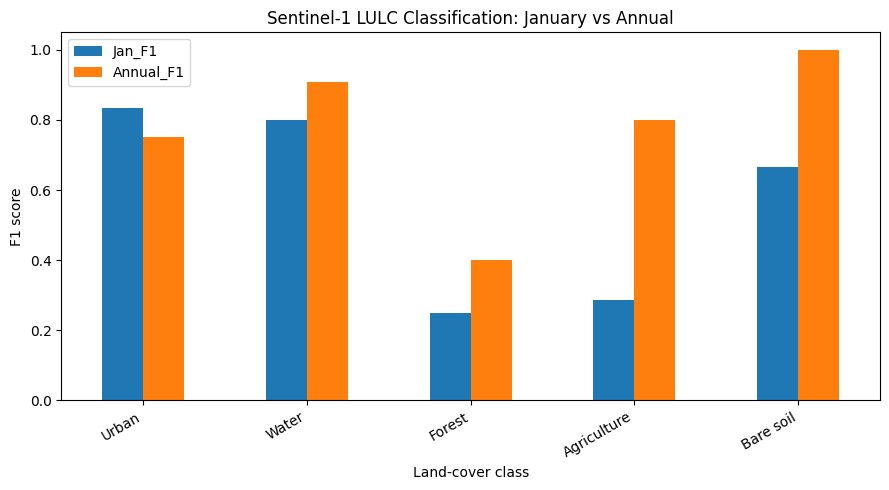

In [32]:
# Plot class-specific F1 comparison

plot_df = (
    class_comparison
    .set_index("class_name")[
        ["Jan_F1", "Annual_F1"]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Sentinel-1 LULC Classification: January vs Annual"
)

ax.set_xlabel("Land-cover class")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Part 11 — Random Forest Variable Importance

Random Forest สามารถรายงานว่า predictor ใดมีบทบาทต่อการแบ่งข้อมูลใน model มากกว่า

ให้ raw importance ของ predictor $j$ เป็น

$$
I_j
$$

เราสามารถ normalize เป็น

$$
I_j^*
=
\frac{I_j}
{\sum_{k=1}^{p} I_k}
$$

ดังนั้น

$$
\sum_j I_j^*=1
$$

### สำคัญ

$$
\text{Variable importance}
\ne
\text{causal effect}
$$

และ monthly SAR predictors มี correlation กันสูง

เช่น

```text
VH_Jul
VH_Aug
VH_Sep
```

อาจมีข้อมูลซ้ำกันบางส่วน

ดังนั้นอย่าตีความว่า predictor ที่อันดับ 1 คือ “เดือนเดียวที่สำคัญทางฟิสิกส์”

In [33]:
# Extract annual Random Forest variable importance

explain = annual_classifier.explain().getInfo()

importance_dict = explain.get(
    "importance",
    {}
)

importance_df = pd.DataFrame({
    "predictor": list(importance_dict.keys()),
    "importance": list(importance_dict.values()),
})

importance_df["normalized_importance"] = (
    importance_df["importance"]
    / importance_df["importance"].sum()
)

importance_df["polarization"] = (
    importance_df["predictor"]
    .str.split("_")
    .str[0]
)

importance_df["month"] = (
    importance_df["predictor"]
    .str.split("_")
    .str[1]
)

importance_df = importance_df.sort_values(
    "normalized_importance",
    ascending=False,
).reset_index(drop=True)

display(importance_df)

,predictor,importance,normalized_importance,polarization,month
0,VH_Mar,40.239520,0.059644,VH,Mar
1,VV_Apr,37.982803,0.056299,VV,Apr
2,VV_Jan,33.001904,0.048916,VV,Jan
3,VH_Feb,31.570942,0.046795,VH,Feb
4,VV_Mar,31.538511,0.046747,VV,Mar
5,VV_Dec,29.401838,0.043580,VV,Dec
6,VH_May,28.820072,0.042718,VH,May
7,VV_Nov,28.690643,0.042526,VV,Nov
8,VH_Dec,28.320758,0.041978,VH,Dec
9,VV_May,28.207472,0.041810,VV,May


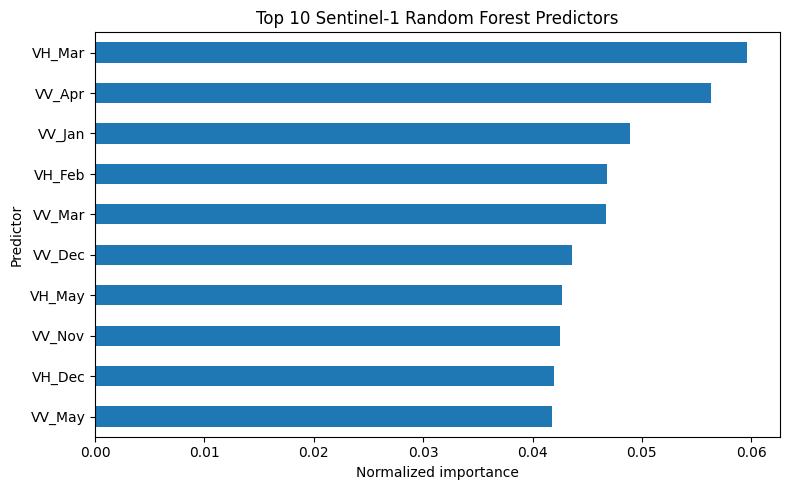

In [34]:
# Plot top 10 annual predictors

top10 = (
    importance_df
    .head(10)
    .sort_values(
        "normalized_importance",
        ascending=True,
    )
)

ax = top10.plot(
    x="predictor",
    y="normalized_importance",
    kind="barh",
    figsize=(8, 5),
    legend=False,
)

ax.set_title(
    "Top 10 Sentinel-1 Random Forest Predictors"
)

ax.set_xlabel("Normalized importance")
ax.set_ylabel("Predictor")

plt.tight_layout()
plt.show()

,month,normalized_importance,month_number
4,Jan,0.083181,1
3,Feb,0.088124,2
7,Mar,0.106392,3
0,Apr,0.097712,4
8,May,0.084528,5
6,Jun,0.079061,6
5,Jul,0.079115,7
1,Aug,0.070937,8
11,Sep,0.077246,9
10,Oct,0.066890,10


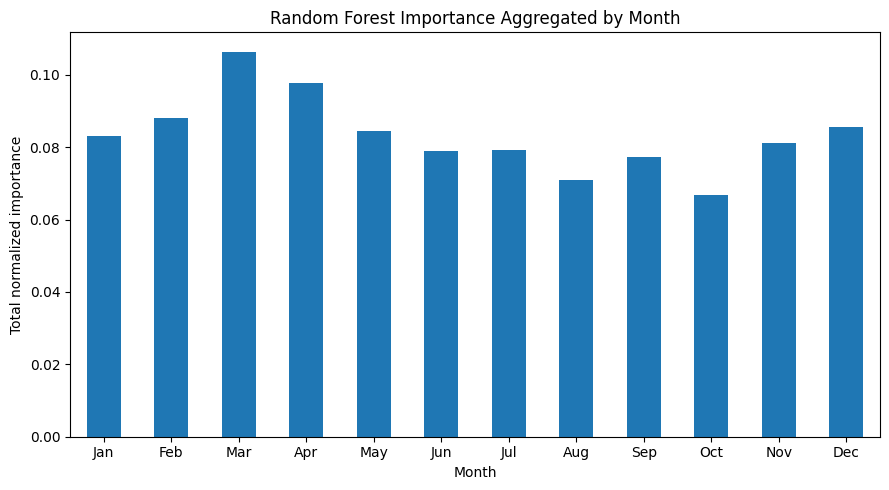

In [35]:
# Aggregate variable importance by month

month_order = {
    label: i + 1
    for i, label in enumerate(MONTH_LABELS)
}

month_importance = (
    importance_df
    .groupby("month", as_index=False)[
        "normalized_importance"
    ]
    .sum()
)

month_importance["month_number"] = (
    month_importance["month"]
    .map(month_order)
)

month_importance = (
    month_importance
    .sort_values("month_number")
)

display(month_importance)

ax = month_importance.plot(
    x="month",
    y="normalized_importance",
    kind="bar",
    figsize=(9, 5),
    legend=False,
)

ax.set_title(
    "Random Forest Importance Aggregated by Month"
)

ax.set_xlabel("Month")
ax.set_ylabel("Total normalized importance")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,polarization,normalized_importance
1,VV,0.51276
0,VH,0.48724


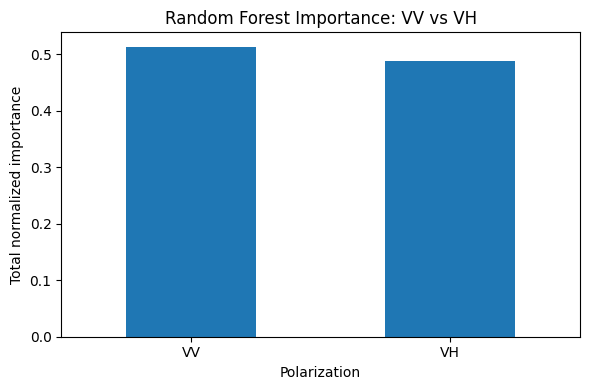

In [36]:
# Aggregate variable importance by polarization

pol_importance = (
    importance_df
    .groupby(
        "polarization",
        as_index=False,
    )["normalized_importance"]
    .sum()
    .sort_values(
        "normalized_importance",
        ascending=False,
    )
)

display(pol_importance)

ax = pol_importance.plot(
    x="polarization",
    y="normalized_importance",
    kind="bar",
    figsize=(6, 4),
    legend=False,
)

ax.set_title(
    "Random Forest Importance: VV vs VH"
)

ax.set_xlabel("Polarization")
ax.set_ylabel("Total normalized importance")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Part 12 — Scientific interpretation

ตอบคำถามโดยใช้ทั้ง

- Confusion Matrix
- PA / UA / F1
- January vs Annual comparison
- variable importance
- SAR temporal profiles จาก Notebook 03

### Classification

1. Water จำแนกได้ดีทั้ง January และ Annual หรือไม่?
2. Urban กับ Forest ยังสับสนกันหรือไม่?
3. Agriculture ได้ประโยชน์จาก full-year temporal information หรือไม่?
4. Bare soil ดีขึ้นหรือแย่ลงเมื่อใช้ข้อมูลทั้งปี?
5. Class ใดมี $\Delta F1$ สูงที่สุด?

### Variable importance

6. เดือนใดมี total importance สูง?
7. VV หรือ VH มี importance รวมมากกว่า?
8. เดือน importance สูงสัมพันธ์กับ temporal variability ของ Agriculture หรือไม่?
9. Predictor อันดับ 1 ควรตีความว่าเป็น “สาเหตุ” หรือไม่? เพราะอะไร?

### Temporal-label question

10. ถ้า Bare soil ในเดือนมกราคมกลายเป็น vegetation ในฤดูฝน แต่ annual model accuracy สูงขึ้น เราควรตีความผลอย่างไร?

> เป้าหมายไม่ใช่แค่หา model ที่ accuracy สูงที่สุด แต่ต้องเข้าใจว่า model กำลังเรียนรู้อะไร

# Part 13 — Export results for QGIS

เราจะ export สองแผนที่เพื่อให้เปิดเปรียบเทียบใน QGIS

```text
PHS_S1_January_RF_LULC_2021.tif
PHS_S1_Annual_RF_LULC_2021.tif
```

Class coding:

```text
0 = Urban
1 = Water
2 = Forest
3 = Agriculture
4 = Bare soil
255 = NoData
```

ใช้

```text
CRS   = EPSG:32647
Scale = 10 m
```

In [37]:
# Export January and Annual classification maps

NO_DATA = 255

jan_export = (
    jan_classified
    .toByte()
    .unmask(NO_DATA)
)

annual_export = (
    annual_classified
    .toByte()
    .unmask(NO_DATA)
)

jan_task = ee.batch.Export.image.toDrive(
    image=jan_export,
    description="PHS_S1_January_RF_LULC_2021",
    folder="GEE_LULC",
    fileNamePrefix="PHS_S1_January_RF_LULC_2021",
    region=study_area,
    scale=10,
    crs="EPSG:32647",
    maxPixels=1e13,
    fileFormat="GeoTIFF",
    formatOptions={
        "cloudOptimized": True,
        "noData": NO_DATA,
    },
)

annual_task = ee.batch.Export.image.toDrive(
    image=annual_export,
    description="PHS_S1_Annual_RF_LULC_2021",
    folder="GEE_LULC",
    fileNamePrefix="PHS_S1_Annual_RF_LULC_2021",
    region=study_area,
    scale=10,
    crs="EPSG:32647",
    maxPixels=1e13,
    fileFormat="GeoTIFF",
    formatOptions={
        "cloudOptimized": True,
        "noData": NO_DATA,
    },
)

jan_task.start()
annual_task.start()

print("January export:", jan_task.status())
print("Annual export:", annual_task.status())

January export: {'state': 'READY', 'description': 'PHS_S1_January_RF_LULC_2021', 'priority': 100, 'creation_timestamp_ms': 1791276767481, 'update_timestamp_ms': 1791276767481, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'W6GESAGTBRLBPDLKU4OI4LXI', 'name': 'projects/teach-gee-github-lulc/operations/W6GESAGTBRLBPDLKU4OI4LXI'}
Annual export: {'state': 'READY', 'description': 'PHS_S1_Annual_RF_LULC_2021', 'priority': 100, 'creation_timestamp_ms': 1791276767997, 'update_timestamp_ms': 1791276767997, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'YHE3TCU6VRAVVK4EDOME2O2S', 'name': 'projects/teach-gee-github-lulc/operations/YHE3TCU6VRAVVK4EDOME2O2S'}


In [38]:
# Export variable-importance table to Google Drive

importance_features = []

for row in importance_df.itertuples(index=False):
    importance_features.append(
        ee.Feature(
            None,
            {
                "predictor": str(row.predictor),
                "importance": float(row.importance),
                "normalized_importance": float(row.normalized_importance),
                "month": str(row.month),
                "polarization": str(row.polarization),
            },
        )
    )

importance_fc = ee.FeatureCollection(
    importance_features
)

importance_task = ee.batch.Export.table.toDrive(
    collection=importance_fc,
    description="PHS_S1_RF_Variable_Importance_2021",
    folder="GEE_LULC",
    fileNamePrefix="PHS_S1_RF_Variable_Importance_2021",
    fileFormat="CSV",
)

importance_task.start()

print(
    "Variable importance export:",
    importance_task.status(),
)

Variable importance export: {'state': 'READY', 'description': 'PHS_S1_RF_Variable_Importance_2021', 'priority': 100, 'creation_timestamp_ms': 1791276768763, 'update_timestamp_ms': 1791276768763, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': '6WUKWGMPHJR36GVECPYL5OUF', 'name': 'projects/teach-gee-github-lulc/operations/6WUKWGMPHJR36GVECPYL5OUF'}


# Exercise — Does more temporal information always help?

สร้างโมเดลเพิ่มอีกหนึ่งชุด

### Model C — First-quarter SAR

ใช้

```text
VV_Jan, VH_Jan
VV_Feb, VH_Feb
VV_Mar, VH_Mar
```

ดังนั้น

$$
p=6
$$

แล้วเปรียบเทียบ

| Model | Predictors | OA | Mean F1 |
|---|---:|---:|---:|
| January | 2 | | |
| Jan–Mar | 6 | | |
| Jan–Dec | 24 | | |

### คำถาม

1. Accuracy เพิ่มตามจำนวน predictors หรือไม่?
2. Agriculture ได้ประโยชน์จาก temporal information ระยะยาวหรือไม่?
3. Bare soil มี temporal-label inconsistency หรือไม่?
4. ถ้า 6 predictors ให้ผลใกล้ 24 predictors เราจำเป็นต้องใช้ทั้งปีหรือไม่?

In [39]:
# Exercise helper — first-quarter predictors

Q1_BANDS = [
    "VV_Jan", "VH_Jan",
    "VV_Feb", "VH_Feb",
    "VV_Mar", "VH_Mar",
]

q1_predictors = (
    annual_stack
    .select(Q1_BANDS)
)

print("Q1 predictors:")
display(Q1_BANDS)

# Continue using the SAME:
# - training_rectangles
# - validation_points
# - Random Forest settings
#
# Then compare with the January and Annual models above.

Q1 predictors:


['VV_Jan', 'VH_Jan', 'VV_Feb', 'VH_Feb', 'VV_Mar', 'VH_Mar']

# Take-home messages

1. GRD asset count ไม่จำเป็นต้องเท่ากับ independent acquisition count
2. Same-date GRD frames ควรถูกพิจารณาร่วมกันก่อนสร้าง temporal composites
3. January model เป็น baseline ที่ใกล้ reference-label period
4. Annual model ใช้ temporal behaviour เป็น predictor เพิ่มเติม
5. Temporal information อาจช่วยบาง classes มากกว่าบาง classes
6. More predictors ไม่ได้รับประกัน higher validation accuracy
7. Water มักแยกง่ายด้วย SAR แต่ class ที่มี backscatter overlap อาจยังยาก
8. Agriculture มี temporal information สูง แต่ label interpretation ต้องระวัง
9. Variable importance ช่วยอธิบาย model แต่ไม่ใช่ causal evidence
10. Correlated monthly predictors อาจแบ่ง importance ระหว่างกัน
11. Same validation locations ทำให้การเปรียบเทียบ model มีความหมายมากขึ้น

## Next

**Notebook 05 — Sentinel-1 + Sentinel-2 Data Fusion**

เราจะเปรียบเทียบ

```text
S2 spectral features
        vs
S1 temporal features
        vs
S1 + S2 fusion
```

โดยใช้

```text
same training geometry
same validation points
same classifier family
```

เพื่อทดสอบว่า optical และ SAR ให้ complementary information ต่อการจำแนก LULC หรือไม่

# References and documentation

- Google Earth Engine — Sentinel-1 Algorithms  
  https://developers.google.com/earth-engine/guides/sentinel1

- Google Earth Engine — Sentinel-1 GRD Data Catalog  
  https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S1_GRD

- Google Earth Engine — Random Forest  
  https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest

- Google Earth Engine — Error Matrix  
  https://developers.google.com/earth-engine/apidocs/ee-featurecollection-errormatrix

- Google Earth Engine — Export Image to Drive  
  https://developers.google.com/earth-engine/apidocs/export-image-todrive

### Teaching note

Notebook นี้ตั้งใจให้เป็น controlled experiment ของ **temporal information**  
โดยไม่เปลี่ยน training locations, training support, classifier family หรือ validation locations